In [42]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [43]:
df=pd.read_csv("dataset/insurance.csv")

In [44]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [50]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [46]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [48]:
df['sex']=np.where(df['sex'].str.lower()=="male",0,1)

In [49]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [53]:
df['region']=df['region'].map({'southwest':1, 'southeast': 2, 'northwest': 3, 'northeast': 4})

In [54]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,1,16884.92400
1,18,0,33.770,1,no,2,1725.55230
2,28,0,33.000,3,no,2,4449.46200
3,33,0,22.705,0,no,3,21984.47061
4,32,0,28.880,0,no,3,3866.85520


In [55]:
df['smoker']=df['smoker'].map({'yes':2,'no':0})

In [56]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,2,1,16884.92400
1,18,0,33.770,1,0,2,1725.55230
2,28,0,33.000,3,0,2,4449.46200
3,33,0,22.705,0,0,3,21984.47061
4,32,0,28.880,0,0,3,3866.85520


In [57]:
df.corr()

,age,sex,bmi,children,smoker,region,charges
age,1.000000,0.020856,0.109272,0.042469,-0.025019,-0.002127,0.299008
sex,0.020856,1.000000,-0.046371,-0.017163,-0.076185,0.004588,-0.057292
bmi,0.109272,-0.046371,1.000000,0.012759,0.003750,-0.157566,0.198341
children,0.042469,-0.017163,0.012759,1.000000,0.007673,-0.016569,0.067998
smoker,-0.025019,-0.076185,0.003750,0.007673,1.000000,0.002181,0.787251
region,-0.002127,0.004588,-0.157566,-0.016569,0.002181,1.000000,0.006208
charges,0.299008,-0.057292,0.198341,0.067998,0.787251,0.006208,1.000000


<Axes: >

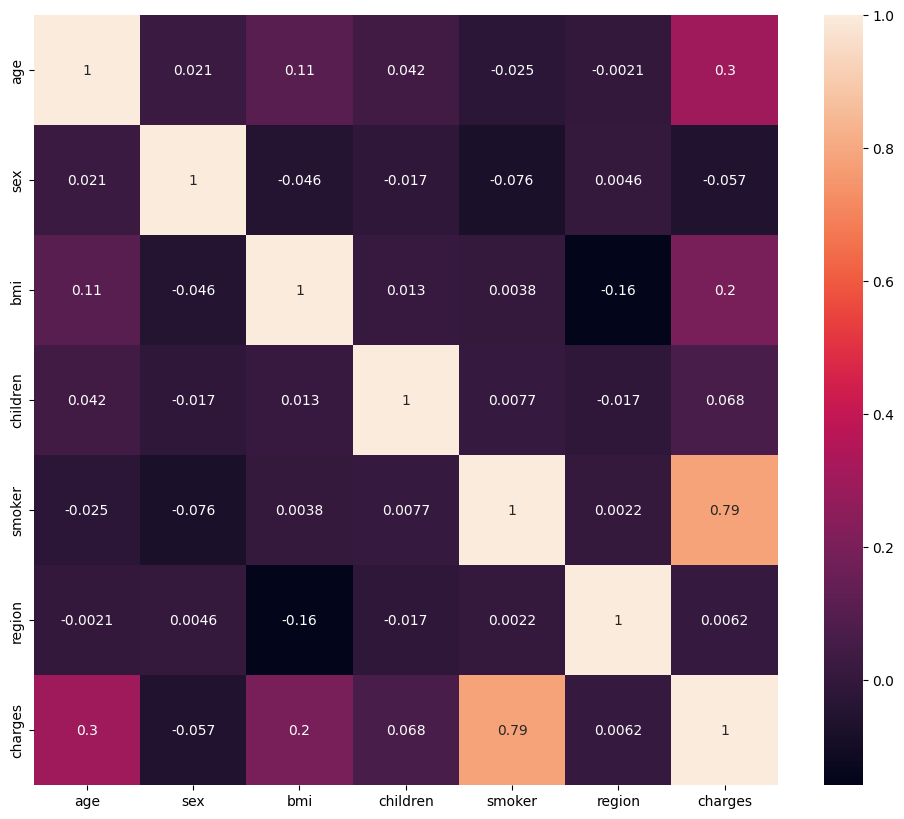

In [59]:
import seaborn as sns
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),annot=True)

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [62]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [63]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [64]:
scaler=StandardScaler()

In [65]:
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import LassoCV
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import ElasticNetCV

In [67]:
LR=LinearRegression()
La=Lasso()
Ri=Ridge()
LaCV=LassoCV()
RiCV=RidgeCV()
El=ElasticNet()
ElCV=ElasticNetCV()

In [68]:
objects=[LR,La,Ri,LaCV,RiCV,El,ElCV]
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [72]:
for object in objects:
    object.fit(x_train,y_train)
    y_pred=object.predict(x_test)
    mae=mean_absolute_error(y_test,y_pred)
    score=r2_score(y_test,y_pred)
    print(f"Mean absolute error for model {object} is : {mae}")
    print(f"R2_Score for model {object} is :{score}")
    print()

Mean absolute error for model LinearRegression() is : 4186.5088983664355
R2_Score for model LinearRegression() is :0.7833463107364537

Mean absolute error for model Lasso() is : 4186.623542226471
R2_Score for model Lasso() is :0.7833293535279202

Mean absolute error for model Ridge() is : 4187.9716854277285
R2_Score for model Ridge() is :0.7833037457661383

Mean absolute error for model LassoCV() is : 4194.248135620977
R2_Score for model LassoCV() is :0.7819422109800034

Mean absolute error for model RidgeCV() is : 4187.971685428944
R2_Score for model RidgeCV() is :0.7833037457661154

Mean absolute error for model ElasticNet() is : 5261.35262506258
R2_Score for model ElasticNet() is :0.6841944311286268

Mean absolute error for model ElasticNetCV() is : 8870.579156385056
R2_Score for model ElasticNetCV() is :0.13768105424193988



In [73]:
import pickle as pkl
pkl.dump(scaler,open('scaler.pkl','wb'))
pkl.dump(La,open('lasso.pkl','wb'))